In [25]:
import pandas as pd
import vectorbt as vbt
from plotly.io import show
from matplotlib import pyplot as plt
import mplfinance as mpf
import seaborn as sns
from tabulate import tabulate

import optuna
from optuna.samplers import RandomSampler, TPESampler

from utils.KrakenHistoricalData import KrakenHistoricalData
from utils.KrakenData import KrakenData
from ggTrader.Utils import *
from ggTrader.Signals import *


In [26]:
top_kraken = [
    "BTC",  # 1 Bitcoin
    "ETH",  # 2 Ethereum
    "XRP",  # 3 XRP
    # "BNB",  # 4 BNB
    "SOL",  # 5 Solana
    "TRX",  # 6 TRON
    "DOGE",  # 7 Dogecoin
    "ADA",  # 8 Cardano
    # "HYPE",  # 9 Hyperliquid
    "LINK",  # 10 Chainlink
    "BCH",  # 11 Bitcoin Cash
    "XLM",  # 12 Stellar
    "SUI",  # 13 Sui
    # "HBAR",  # 14 Hedera
    "AVAX",  # 15 Avalanche
    "ZEC",  # 16 Zcash
    "LTC",  # 17 Litecoin
    "XMR",  # 18 Monero
    "SHIB",  # 19 Shiba Inu
    # "TON",  # 20 Toncoin
    # "CRO",  # 21 Crypto.com
    "DOT",  # 22 Polkadot
    # "MNT",  # 23 Mantle
    # "TAO",  # 24 Bittensor
    "UNI",  # 25 Uniswap
]

Walk Forward Optimization

In [43]:
# setup
k = KrakenHistoricalData()

start_equity = 1000
# symbols = ["BTC", "ETH", "LTC"]
symbols = top_kraken[:1]
interval = "4h"
n_trials = 100
min_trades = 15
n_splits = 3
test_ratio = 0.334
# sampler = RandomSampler(seed=42)  # optional seed for reproducibility
sampler = TPESampler(seed=42)

# Time Range
end = pd.to_datetime("2025-09-30").tz_localize('UTC')
# start = end - pd.Timedelta(days=30 * 6)
start = pd.to_datetime("2023-01-01").tz_localize('UTC')

# Indicator Params
params_default = {'sar_acceleration': 0.03,
                  'sar_maximum': 0.3,
                  'atr_multiplier': 5.5,
                  'adx_threshold': 25,
                  'adx_length': 14,
                  'atr_length': 14,
                  'use_dmp_cross': False,
                  }
params = params_default.copy()
# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

data_df = k.get_ohlcv_df(symbols, interval=interval, start=start, end=end)
close = data_df.xs('close', axis=1, level=1)
print(close.info())
print(close.columns)
print(data_df.head())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6019 entries, 2023-01-01 00:00:00+00:00 to 2025-09-30 00:00:00+00:00
Freq: 4h
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   BTC     6019 non-null   float32
dtypes: float32(1)
memory usage: 70.5 KB
None
Index(['BTC'], dtype='object', name='symbol')
symbol                              BTC                              \
                                   open          high           low   
Datetime                                                              
2023-01-01 00:00:00+00:00  16528.699219  16530.000000  16505.199219   
2023-01-01 04:00:00+00:00  16519.300781  16542.400391  16506.900391   
2023-01-01 08:00:00+00:00  16512.400391  16538.400391  16490.000000   
2023-01-01 12:00:00+00:00  16500.199219  16550.000000  16497.699219   
2023-01-01 16:00:00+00:00  16550.000000  16573.099609  16531.199219   

symbol                                                           

Computed test_size=1205, max_train_size=2403


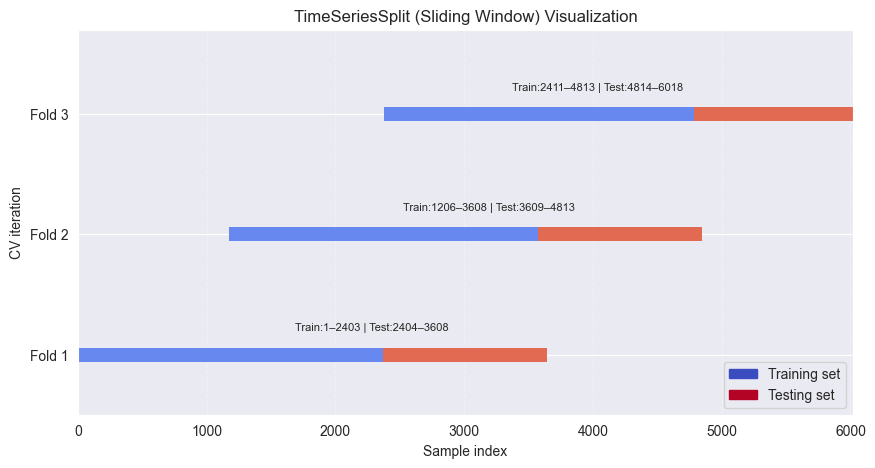

   Fold               Start                 End          Start Test  \
0     1 2023-01-01 04:00:00 2024-02-05 12:00:00 2024-02-05 16:00:00   
1     2 2023-07-21 00:00:00 2024-08-24 08:00:00 2024-08-24 12:00:00   
2     3 2024-02-06 20:00:00 2025-03-13 04:00:00 2025-03-13 08:00:00   

             End Test      Train Period       Test Period  
0 2024-08-24 08:00:00 400 days 08:00:00 200 days 16:00:00  
1 2025-03-13 04:00:00 400 days 08:00:00 200 days 16:00:00  
2 2025-09-30 00:00:00 400 days 08:00:00 200 days 16:00:00  


In [28]:
# Train split

tscv, test_size, max_train_size = make_end_anchored_tscv(n_samples=len(data_df), n_splits=n_splits,
                                                         test_ratio=test_ratio)
print(f"Computed test_size={test_size}, max_train_size={max_train_size}")

fig, ax = plt.subplots(figsize=(10, 5))
plot_cv_indices(tscv, data_df.index, ax, n_splits)
plt.show()
# 4. Print fold ranges
rows = []
for i, (tr, tt) in enumerate(tscv.split(data_df.index), 1):
    start_train = data_df.index[tr[0]].tz_convert(None)
    end_train = data_df.index[tr[-1]].tz_convert(None)
    start_test = data_df.index[tt[0]].tz_convert(None)
    end_test = data_df.index[tt[-1]].tz_convert(None)

    rows.append({
        'Fold': i,
        'Start': start_train,
        'End': end_train,
        'Start Test': start_test,
        'End Test': end_test,
        'Train Period': end_train - start_train,
        'Test Period': end_test - start_test
    })

dur_df = pd.DataFrame(rows)
print(dur_df)


Optuna setup

In [29]:
best_params_list = []
value_list = []
fold_test_performance_list = []
performance = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Profit Factor', 'Total Return [%]']

for i, (tr, tt) in enumerate(tscv.split(data_df.index), 1):
    df_train = data_df.iloc[tr]
    df_test = data_df.iloc[tt]

    print(f"{symbols} Fold {i}/{n_splits}:")
    close = df_train.xs('close', axis=1, level=1)
    high = df_train.xs('high', axis=1, level=1)
    low = df_train.xs('low', axis=1, level=1)
    open = df_train.xs('open', axis=1, level=1)


    def objective(trial: optuna.Trial):
        # Entry
        params['adx_threshold'] = trial.suggest_int("adx_threshold", 2, 80, step=2)  #
        params['adx_length'] = trial.suggest_int("adx_length", 2, 18)
        params['sar_acceleration'] = trial.suggest_float("sar_acceleration", 0.04, 0.04)  # default .02
        params['sar_maximum'] = trial.suggest_float("sar_maximum", 0.3, 0.3)  # default .2
        params['use_dmp_cross'] = trial.suggest_categorical("use_dmp_cross", [False, False])

        # Exit
        params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 4.5, 6.5, step=0.5)
        params['atr_length'] = trial.suggest_int("atr_length", 12, 16)

        entries, exits, stop_df, price_for_orders = calc_signals(close=close,
                                                                 high=high,
                                                                 low=low,
                                                                 open_=open,
                                                                 **params,
                                                                 )
        pf = vbt.Portfolio.from_signals(
            close=price_for_orders,
            entries=entries,
            exits=exits,
            init_cash=start_equity,
            fees=transaction_fee,
            slippage=0.0002
        )
        stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
        sharpe = stats_df.loc["Sharpe Ratio"].mean()
        low_trades = stats_df.loc["Total Trades"].min() < min_trades
        if sharpe is None or math.isnan(sharpe) or math.isinf(sharpe):
            raise optuna.exceptions.TrialPruned("Invalid objective (NaN/Inf).")
        elif low_trades:
            raise optuna.exceptions.TrialPruned("Invalid objective (low trades).")
        wide = stats_df_to_wide(stats_df, trial.number)
        params_df = pd.DataFrame(params, index=wide.index)
        trial_summary = pd.concat([wide, params_df], axis=1)
        trials_summary_list.append(trial_summary)

        return sharpe


    trials_summary_list = []

    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials)
    trials_summary = pd.concat(trials_summary_list, axis=0).reset_index(drop=True)

    top_10_pct = int(n_trials * 0.1)
    top_runs = trials_summary.sort_values('Sharpe Ratio', ascending=False).groupby('symbol').head(top_10_pct)
    best_params = study.best_params
    best_params_list.append(best_params)

    #-------- backtest best parameters on test set-------
    for param in best_params.keys():
        params[param] = top_runs[param].mean()  # get average of 10% of runs
        # params[param] = best_params[param]

    close = df_test.xs('close', axis=1, level=1)
    high = df_test.xs('high', axis=1, level=1)
    low = df_test.xs('low', axis=1, level=1)
    open = df_test.xs('open', axis=1, level=1)
    entries, exits, stop_df, price_for_orders = calc_signals(close=close,
                                                             high=high,
                                                             low=low,
                                                             open_=open,
                                                             **params,
                                                             )

    pf = vbt.Portfolio.from_signals(
        close=price_for_orders,
        entries=entries,
        exits=exits,
        init_cash=start_equity,
        fees=transaction_fee,
        slippage=0.0002
    )
    stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
    sharpe_series = stats_df.loc["Sharpe Ratio"]
    # Sharpe gets filtered in case there are low trades in the small test window.
    sharpe_mean = sharpe_series.replace([np.inf, -np.inf], np.nan).mean(skipna=True)
    sharpe = sharpe_mean
    value_list.append(sharpe)

    fold_test_performance_wide = stats_df_to_wide(stats_df, i)
    fold_test_performance_list.append(fold_test_performance_wide)

fold_test_performance_df = pd.concat(fold_test_performance_list, axis=0).reset_index(drop=True)
print(f"...Optimization Complete")


['BTC'] Fold 1/3:


[I 2025-11-11 22:58:41,935] A new study created in memory with name: no-name-50234a65-d287-4367-b5ce-2698f20cc1ea
[I 2025-11-11 22:58:42,077] Trial 0 finished with value: 2.540873825062694 and parameters: {'adx_threshold': 30, 'adx_length': 18, 'sar_acceleration': 0.04, 'sar_maximum': 0.3, 'use_dmp_cross': False, 'atr_multiplier': 4.5, 'atr_length': 12}. Best is trial 0 with value: 2.540873825062694.
[I 2025-11-11 22:58:42,206] Trial 1 finished with value: 1.52809564063048 and parameters: {'adx_threshold': 6, 'adx_length': 16, 'sar_acceleration': 0.04, 'sar_maximum': 0.3, 'use_dmp_cross': False, 'atr_multiplier': 4.5, 'atr_length': 16}. Best is trial 0 with value: 2.540873825062694.
[I 2025-11-11 22:58:42,330] Trial 2 pruned. Invalid objective (low trades).
[I 2025-11-11 22:58:42,463] Trial 3 finished with value: 1.6951518251199964 and parameters: {'adx_threshold': 36, 'adx_length': 6, 'sar_acceleration': 0.04, 'sar_maximum': 0.3, 'use_dmp_cross': False, 'atr_multiplier': 5.0, 'atr_len

['BTC'] Fold 2/3:


[I 2025-11-11 22:58:56,863] Trial 1 pruned. Invalid objective (low trades).
[I 2025-11-11 22:58:56,987] Trial 2 pruned. Invalid objective (low trades).
[I 2025-11-11 22:58:57,112] Trial 3 finished with value: 1.1611242249413123 and parameters: {'adx_threshold': 30, 'adx_length': 3, 'sar_acceleration': 0.04, 'sar_maximum': 0.3, 'use_dmp_cross': False, 'atr_multiplier': 5.0, 'atr_length': 12}. Best is trial 3 with value: 1.1611242249413123.
[I 2025-11-11 22:58:57,231] Trial 4 pruned. Invalid objective (low trades).
[I 2025-11-11 22:58:57,565] Trial 5 pruned. Invalid objective (low trades).
[I 2025-11-11 22:58:57,702] Trial 6 finished with value: 0.9078486482154781 and parameters: {'adx_threshold': 42, 'adx_length': 9, 'sar_acceleration': 0.04, 'sar_maximum': 0.3, 'use_dmp_cross': False, 'atr_multiplier': 4.5, 'atr_length': 15}. Best is trial 3 with value: 1.1611242249413123.
[I 2025-11-11 22:58:57,850] Trial 7 finished with value: 1.1934879569478853 and parameters: {'adx_threshold': 26, 

['BTC'] Fold 3/3:


[I 2025-11-11 22:59:11,983] Trial 0 pruned. Invalid objective (low trades).
[I 2025-11-11 22:59:12,110] Trial 1 pruned. Invalid objective (low trades).
[I 2025-11-11 22:59:12,239] Trial 2 finished with value: 1.0989123486969026 and parameters: {'adx_threshold': 10, 'adx_length': 7, 'sar_acceleration': 0.04, 'sar_maximum': 0.3, 'use_dmp_cross': False, 'atr_multiplier': 5.5, 'atr_length': 15}. Best is trial 2 with value: 1.0989123486969026.
[I 2025-11-11 22:59:12,363] Trial 3 finished with value: 1.1034326970408868 and parameters: {'adx_threshold': 30, 'adx_length': 18, 'sar_acceleration': 0.04, 'sar_maximum': 0.3, 'use_dmp_cross': False, 'atr_multiplier': 5.5, 'atr_length': 13}. Best is trial 3 with value: 1.1034326970408868.
[I 2025-11-11 22:59:12,487] Trial 4 finished with value: 0.6244471509143137 and parameters: {'adx_threshold': 24, 'adx_length': 2, 'sar_acceleration': 0.04, 'sar_maximum': 0.3, 'use_dmp_cross': False, 'atr_multiplier': 4.5, 'atr_length': 13}. Best is trial 3 with v

...Optimization Complete


C:\Users\gkuep\AppData\Local\Temp\ipykernel_8220\2080253447.py:96: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [48]:
print(fold_test_performance_df.head())

    id symbol                     Start                       End  \
0  1.0    BTC 2024-02-05 16:00:00+00:00 2024-08-24 08:00:00+00:00   
1  2.0    BTC 2024-08-24 12:00:00+00:00 2025-03-13 04:00:00+00:00   
2  3.0    BTC 2025-03-13 08:00:00+00:00 2025-09-30 00:00:00+00:00   

             Period  Start Value      End Value  Total Return [%]  \
0 200 days 20:00:00     100000.0  105448.327911          5.448328   
1 200 days 20:00:00     100000.0  144977.258542         44.977259   
2 200 days 20:00:00     100000.0  130058.596579         30.058597   

   Benchmark Return [%]  Max Gross Exposure [%]  ...  Avg Winning Trade [%]  \
0             49.727416                   100.0  ...               6.152743   
1             29.892230                   100.0  ...              16.097541   
2             38.001204                   100.0  ...              10.798352   

   Avg Losing Trade [%] Avg Winning Trade Duration  Avg Losing Trade Duration  \
0             -3.338480           15 days 02:24:

In [41]:
performance = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Profit Factor', 'Total Return [%]',
               'Benchmark Return [%]', 'Total Trades']

print("\nWalk Forward Optimization Results:")
rows = [{**p, "score": float(s), "fold": i + 1} for i, (p, s) in enumerate(zip(best_params_list, value_list))]
df_result = pd.DataFrame(rows).set_index("fold")
print(df_result.to_string())
result_stats = df_result.describe()

print("\nWalk Forward Optimization Stats:")
print(result_stats.to_string())

print("\nFold Test Performance:")
cols = ['id', 'symbol'] + performance
print(fold_test_performance_df[cols].sort_values(by=['Sharpe Ratio'], ascending=[False]).to_string())
print(fold_test_performance_df[cols].groupby('symbol').mean().sort_values(by=['Sharpe Ratio'], ascending=[False]))
print(fold_test_performance_df[cols].describe())


Walk Forward Optimization Results:
      adx_threshold  adx_length  sar_acceleration  sar_maximum  use_dmp_cross  atr_multiplier  atr_length     score
fold                                                                                                               
1                32          16              0.04          0.3          False             4.5          13  0.441479
2                26          17              0.04          0.3          False             5.5          12  1.622866
3                34           3              0.04          0.3          False             5.5          12  1.566388

Walk Forward Optimization Stats:
       adx_threshold  adx_length  sar_acceleration  sar_maximum  atr_multiplier  atr_length     score
count       3.000000     3.00000              3.00          3.0        3.000000    3.000000  3.000000
mean       30.666667    12.00000              0.04          0.3        5.166667   12.333333  1.210244
std         4.163332     7.81025            

Run final backtest with average parameters

In [55]:
# reset params
params = params_default.copy()
for param in params.keys():
    value = df_result[param].mean()
    params[param] = value

print(tabulate(params.items(), headers=['Parameter', 'Value']))

close = data_df.xs('close', axis=1, level=1)
high = data_df.xs('high', axis=1, level=1)
low = data_df.xs('low', axis=1, level=1)
open = data_df.xs('open', axis=1, level=1)

entries, exits, stop_df, price_for_orders = calc_signals(close=close,
                                                         high=high,
                                                         low=low,
                                                         open_=open,
                                                         **params,
                                                         )

pf = vbt.Portfolio.from_signals(
    close=price_for_orders,
    entries=entries,
    exits=exits,
    init_cash=start_equity,
    fees=transaction_fee,
    slippage=0.0002
)

Parameter            Value
----------------  --------
sar_acceleration   0.04
sar_maximum        0.3
atr_multiplier     5.16667
adx_threshold     30.6667
adx_length        12
atr_length        12.3333
use_dmp_cross      0


In [56]:
stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
final_test_performance_wide = stats_df_to_wide(stats_df, 0)
print(final_test_performance_wide[cols].sort_values('Sharpe Ratio', ascending=False).to_string())

    id symbol  Sharpe Ratio  Sortino Ratio  Calmar Ratio  Profit Factor  Total Return [%]  Benchmark Return [%]  Total Trades
0  0.0    BTC      1.294882       1.924039      1.725793       1.660901        239.335694            592.708492            61


In [57]:
symbols_pf = [symbol_pf for _, symbol_pf in pf.wrapper.columns]
# symbols_pf_index = symbols_pf.index(symbols[0])
for symbol in symbols:
    symbol_pf_index = symbols_pf.index(symbol)
    one_pf = pf[pf.wrapper.columns[symbol_pf_index]]
    one_pf.plot(subplots=['trades', 'trade_pnl', 'cum_returns'], width=1200, title=f'{symbol}').show()

## Latest Data TestCase
Test on latest result for the last 3 months

In [58]:
kd = KrakenData()

df_latest = kd.fetch_ohlcv_df(kd.kraken, symbols[0], timeframe='4h', limit=700)
symbols = ['BTC']
metrics = ['open', 'high', 'low', 'close']
df = df_latest[metrics].copy()
columns = pd.MultiIndex.from_product([symbols, metrics], names=['symbol', 'metric'])
df.columns = columns
print(df.head())

close = df.xs('close', axis=1, level=1)
high = df.xs('high', axis=1, level=1)
low = df.xs('low', axis=1, level=1)
open = df.xs('open', axis=1, level=1)

entries, exits, stop_df, price_for_orders = calc_signals(close=close,
                                                         high=high,
                                                         low=low,
                                                         open_=open,
                                                         **params,
                                                         )

pf = vbt.Portfolio.from_signals(
    close=price_for_orders,
    entries=entries,
    exits=exits,
    init_cash=start_equity,
    fees=transaction_fee,
    slippage=0.0002
)



symbol                          BTC                              
metric                         open      high       low     close
datetime                                                         
2025-07-18 16:00:00+00:00  117939.7  118038.0  117232.1  117444.1
2025-07-18 20:00:00+00:00  117444.1  118013.9  116929.6  118011.9
2025-07-19 00:00:00+00:00  118011.9  118419.0  117731.4  118332.8
2025-07-19 04:00:00+00:00  118332.8  118443.0  118175.9  118254.1
2025-07-19 08:00:00+00:00  118254.1  118550.0  118075.0  118393.7


In [59]:
stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
final_test_performance_wide = stats_df_to_wide(stats_df, 0)
print(final_test_performance_wide[cols].sort_values('Sharpe Ratio', ascending=False).to_string())

    id symbol  Sharpe Ratio  Sortino Ratio  Calmar Ratio  Profit Factor  Total Return [%]  Benchmark Return [%]  Total Trades
0  0.0    BTC     -0.290845       -0.40302     -0.699873       0.734485         -4.335302            -11.881482             9


In [60]:
symbols_pf = [symbol_pf for _, symbol_pf in pf.wrapper.columns]
# symbols_pf_index = symbols_pf.index(symbols[0])
for symbol in symbols:
    symbol_pf_index = symbols_pf.index(symbol)
    one_pf = pf[pf.wrapper.columns[symbol_pf_index]]
    one_pf.plot(subplots=['trades', 'trade_pnl', 'cum_returns'], width=1200, title=f'{symbol}').show()